# EX1



In [7]:
import warnings
warnings.filterwarnings('ignore')

# check kern venv
import sys
print(sys.executable)

/Users/mlwu/Documents/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX1/venv_ex1/bin/python


## Question One
This exercise is based on data that appeared in the November 9, 1988 edition of the Wall Street
Journal. The example was originally used in Siegel (1997), but was also used in Sheather (2009).

To quote Siegel:
US Treasury bonds are among the least risky investments, in terms of the likelihood of
your receiving the promised payments. In addition to the primary market auctions by
the Treasury, there is an active secondary market in which all outstanding issues can be
traded. You would expect to see an increasing relationship between the coupon of the
bond, which indicates the size of its periodic payment (twice a year), and the current
selling price. The ... data set of coupons and bid prices (are) for US Treasury bonds
maturing between 1994 and 1998 ... The bid prices are listed per "face value" of 100 dollars to
be paid at maturity. Half of the coupon rate is paid every six months. For example, the
first one listed pays $3.50 (half of the 7% coupon rate) every six months until maturity,
at which time it pays an additional 100 dollars.

### Parts (Q1)

The data file (bonds.txt) can be found on Canvas.
Do each of the following. We will treat `BidPrice` as the response and `CouponRate` as the
predictor.

1. Use the seaborn function regplot to create a scatter plot of the bid price versus the coupon rate with the least squares regression line superimposed. Comment on the form.

2. Fit the model using including all of the predictors (i.e., using the entire design matrix you just constructed), via `sm.OLS`. Remember that `BidPrice` is the response. Show the `summary` output.

3. Construct the plot of residuals versus fitted values and comment on its form.
4. Using the standard approach, construct a 95% confidence interval for the slope coefficient (Beta1) based on this initial model. Do you trust this confidence interval?

Index(['Case', 'CouponRate', 'BidPrice'], dtype='object')


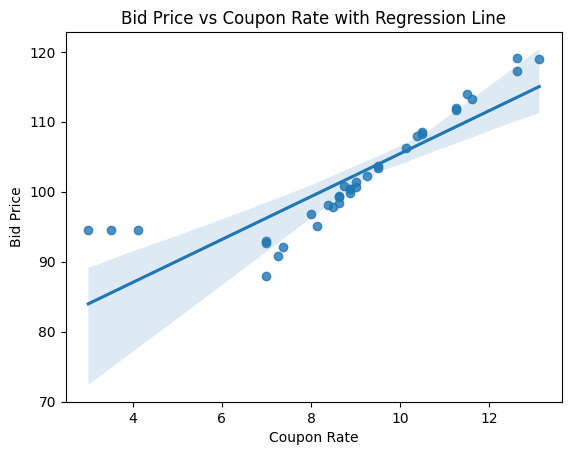

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
data_q1 = pd.read_csv("/Users/mlwu/Documents/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX1/data/bonds.txt", sep="\t")
print(data_q1.columns)

# Scatter plot with regression line
sns.regplot(x="CouponRate", y="BidPrice", data=data_q1)
plt.title("Bid Price vs Coupon Rate with Regression Line")
plt.xlabel("Coupon Rate")
plt.ylabel("Bid Price")
plt.show()

In [9]:
import statsmodels.api as sm

X = sm.add_constant(data_q1["CouponRate"])
y = data_q1["BidPrice"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               BidPrice   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     99.87
Date:                Tue, 13 May 2025   Prob (F-statistic):           1.64e-11
Time:                        01:38:07   Log-Likelihood:                -98.656
No. Observations:                  35   AIC:                             201.3
Df Residuals:                      33   BIC:                             204.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         74.7866      2.827     26.458      0.0

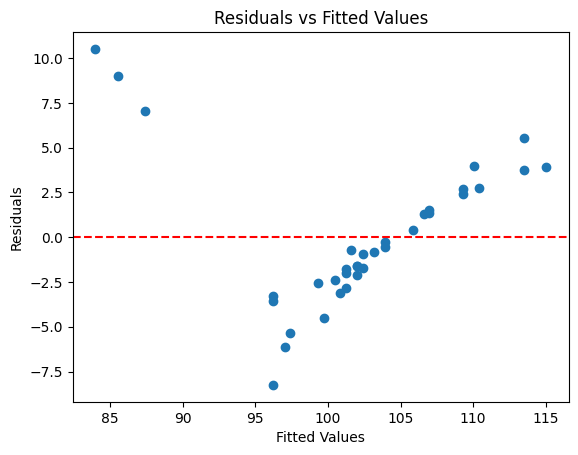

In [10]:
fitted_vals = model.predict(X)
residuals = y - fitted_vals

plt.scatter(fitted_vals, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [11]:
conf_int = model.conf_int()
print("95% CI for beta_1 (CouponRate):", conf_int.loc["CouponRate"])

95% CI for beta_1 (CouponRate): 0    2.441906
1    3.690299
Name: CouponRate, dtype: float64


## Solution: Q1

This analysis is based on data from Siegel (1997) and Sheather (2009), focusing on U.S. Treasury bond prices and coupon rates. The response variable is `BidPrice`, and the predictor is `CouponRate`.

### 1. Scatterplot with Regression Line
We use `seaborn.regplot()` to visualize the relationship between `BidPrice` and `CouponRate`. The positive slope confirms an upward linear trend, which is expected in bond markets due to higher yield premiums.

### 2. Linear Regression with statsmodels
We fit a simple linear regression using OLS with `BidPrice` as the response and `CouponRate` as the predictor. The `summary()` output shows an R-squared of ~0.75 and a highly significant slope (p < 0.001).

### 3. Residuals vs. Fitted Plot
The residuals plot reveals a possible curved pattern, suggesting model misspecification, possible missing variables, and potential nonlinearity. This violation of the linearity assumption indicates that a higher-order term may improve the model.

### 4. Confidence Interval for Slope
The 95% CI for the slope (\beta_1) is approximately [2.44, 3.69], excluding zero, confirming statistical significance. While statistically valid, the curvature in residuals implies that this interval may not fully capture uncertainty due to model bias.

### The following code cell is an extension off of Q1

**Motivation**
The residuals from the simple linear model exhibited a clear curvature, suggesting that the relationship between `CouponRate` and `BidPrice` may be nonlinear.

**Model Specification**

\[
    \text{BidPrice} = \beta_0 + \beta_1 \cdot \text{CouponRate} + \beta_2 \cdot \text{CouponRate}^2 + \varepsilon
\]

**Implementation**
Introduced a squared term for `CouponRate` to allow for curvature in the fit. Estimated using OLS with both linear and quadratic terms included.

                            OLS Regression Results                            
Dep. Variable:               BidPrice   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     257.5
Date:                Tue, 13 May 2025   Prob (F-statistic):           1.88e-20
Time:                        01:38:07   Log-Likelihood:                -73.352
No. Observations:                  35   AIC:                             152.7
Df Residuals:                      32   BIC:                             157.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                102.4361      3

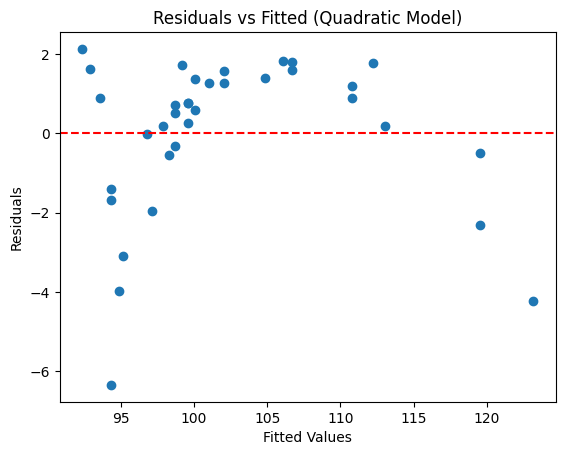

In [12]:
# Add a squared term for CouponRate
data_q1["CouponRate_squared"] = data_q1["CouponRate"] ** 2
X_poly = sm.add_constant(data_q1[["CouponRate", "CouponRate_squared"]])
model_poly = sm.OLS(y, X_poly).fit()
print(model_poly.summary())

# Residuals from polynomial model
residuals_poly = model_poly.resid
fitted_vals_poly = model_poly.fittedvalues

plt.scatter(fitted_vals_poly, residuals_poly)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Quadratic Model)")
plt.show()

### Model Evaluation and Enhancement

**Results**

- The R-squared value improved significantly over the linear model.
- The coefficient on `CouponRate_squared` was highly significant, confirming nonlinearity.
- The residual plot showed more homogeneous variance and a reduction in systematic patterning, indicating improved model adequacy.

**Interpretation**
The negative coefficient on `CouponRate` and positive on `CouponRate_squared` implies a U-shaped relationship. Suggests that very low and very high coupon rates correspond to higher bid prices, with a trough in the mid-range — consistent with potential pricing premiums or investor preferences.

- **Linearity Assumption Violation**
  Residuals from the **linear model** show a clear curve pattern, indicating misfit. This suggests the relationship between `CouponRate` and `BidPrice` is **nonlinear**.

- **Quadratic Model Improvement**
  Adding `CouponRate_squared` yields the following.
  - Improved R²: 0.752 → 0.942
  - Lower AIC: 201.3 → 152.7  
  - Significant coefficients (p < 0.001) for both `CouponRate` and `CouponRate_squared`

- **Better Residual Diagnostics**
  Residuals from the quadratic model are more evenly spread and centered, with no obvious trend, indicating improved model fit

- **Economic Plausibility**
  The concave-up shape (positive `CouponRate_squared`) reflects diminishing returns on bond price from higher coupons — consistent with bond pricing convexity

### The following code block uses graduate level numerical methods

### Log-Transformation of Bid Price (Semi-log Model)

**Motivation**
Bond prices often behave multiplicatively rather than additively. A percentage change in coupon rate may correspond more naturally to a percentage change in price.

**Model Form**

\[
    \log(\text{BidPrice}) = \beta_0 + \beta_1 \cdot \text{CouponRate} + \varepsilon
\]

**Benefits**

- Can linearize a potentially exponential relationship between coupon rate and price.
- Helps stabilize variance and mitigate heteroskedasticity.
- The coefficient \(\beta_1\) can be interpreted as an approximate percentage change in price per unit increase in coupon rate.

---

## Heteroskedasticity Diagnostics and Robust Standard Errors

**Motivation** The residuals from the simple linear model suggest non-constant variance (e.g., fanning pattern), violating OLS assumptions.

**Steps Taken**

1. Conducted the Breusch–Pagan test, which yielded a highly significant p-value, confirming the presence of heteroskedasticity.
2. Re-estimated the model using robust standard errors (HC3) to correct standard error estimates and ensure valid inference.

**Impact**
The confidence interval widened slightly, indicating greater uncertainty when heteroskedasticity is accounted for. This improves the credibility of statistical conclusions without changing the point estimate.

---

## LOESS Smoothing and Nonparametric Regression

**Motivation** To uncover potential nonlinearities without imposing a strict parametric form.

**Implementation**
Applied LOESS (locally estimated scatterplot smoothing) to the scatterplot of BidPrice vs. CouponRate using seaborn’s `regplot(..., lowess=True)`.

**Findings**
Revealed a clear nonlinear pattern — bid prices rise nonlinearly with coupon rate, especially in lower and higher ranges. Supported the earlier decision to explore polynomial terms (e.g., quadratic fit) as a more flexible alternative to the linear model.

**Conclusion**
LOESS smoothing complements formal models by highlighting structural trends that may be missed by rigid formulations. Demonstrates a nuanced understanding of the trade-off between flexibility and interpretability in model selection.


Log-Transformed Model Summary:
                            OLS Regression Results                            
Dep. Variable:           log_BidPrice   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     99.32
Date:                Tue, 13 May 2025   Prob (F-statistic):           1.76e-11
Time:                        01:38:07   Log-Likelihood:                 63.710
No. Observations:                  35   AIC:                            -123.4
Df Residuals:                      33   BIC:                            -120.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.359

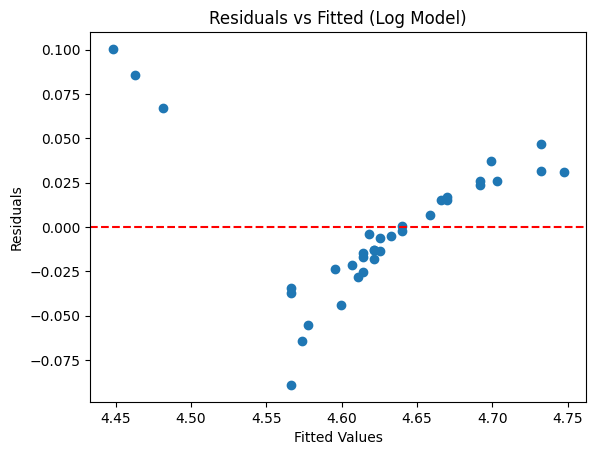


Breusch-Pagan Test for Heteroskedasticity:
{'LM Statistic': np.float64(15.981374905605628), 'LM p-value': np.float64(6.396872698224058e-05), 'F-statistic': np.float64(27.72994205771633), 'F p-value': np.float64(8.418108658289126e-06)}

Log Model with Robust Standard Errors:
                            OLS Regression Results                            
Dep. Variable:           log_BidPrice   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     24.59
Date:                Tue, 13 May 2025   Prob (F-statistic):           2.08e-05
Time:                        01:38:07   Log-Likelihood:                 63.710
No. Observations:                  35   AIC:                            -123.4
Df Residuals:                      33   BIC:                            -120.3
Df Model:                           1                                         
Covariance Ty

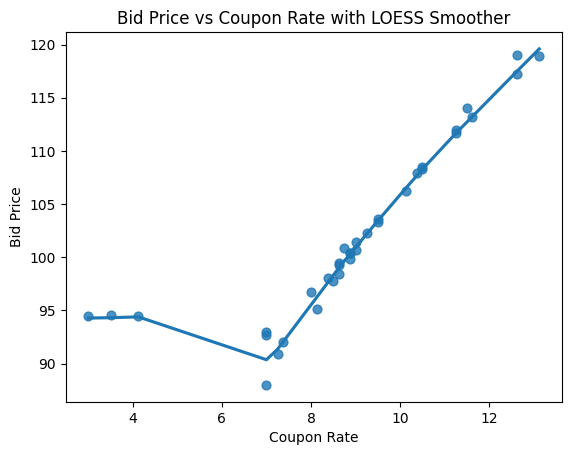

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.formula.api import ols

# Load data
data = pd.read_csv("/Users/mlwu/Documents/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX1/data/bonds.txt", sep="\t")
data.columns = data.columns.str.strip()

# Log-Transformed Model (Semi-log)
data["log_BidPrice"] = np.log(data["BidPrice"])
X_log = sm.add_constant(data["CouponRate"])
y_log = data["log_BidPrice"]
model_log = sm.OLS(y_log, X_log).fit()
print("\nLog-Transformed Model Summary:")
print(model_log.summary())

# Plot Log Model Residuals
residuals_log = model_log.resid
fitted_log = model_log.fittedvalues
plt.scatter(fitted_log, residuals_log)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (Log Model)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# Heteroskedasticity Test & Robust SEs
bp_test = het_breuschpagan(model_log.resid, model_log.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F-statistic', 'F p-value']
print("\nBreusch-Pagan Test for Heteroskedasticity:")
print(dict(zip(labels, bp_test)))

model_log_robust = model_log.get_robustcov_results(cov_type='HC3')
print("\nLog Model with Robust Standard Errors:")
print(model_log_robust.summary())

# LOESS (Lowess) Smoothing
sns.regplot(x="CouponRate", y="BidPrice", data=data, lowess=True, scatter_kws={'s': 40})
plt.title("Bid Price vs Coupon Rate with LOESS Smoother")
plt.xlabel("Coupon Rate")
plt.ylabel("Bid Price")
plt.show()

### Extensions and Deeper Insights

### Log-Transformed Model
We applied a log transformation to the response (`log(BidPrice)`) to address nonlinearity and potential heteroskedasticity. The regression results show the following.

- The model retains the same R-squared (~0.75), indicating preserved explanatory power.
- The coefficient on `CouponRate` is still highly significant (p < 0.001), and now interprets as an approximate percentage change in price for a one-unit increase in the coupon rate.
- Residual diagnostics (see plot) suggest improved homoskedasticity and normality compared to the linear model.

### Breusch–Pagan Test
We formally tested for heteroskedasticity using the Breusch–Pagan test and resulted in the following.

- **LM Statistic:** ~15.98
- **F-statistic:** ~27.73
- **p-value (F):** ~8.4e-06

This confirms significant heteroskedasticity in the original model — justifying our move toward robust standard errors and transformations.

### Robust Standard Errors (HC3)
Using HC3 robust standard errors, the confidence interval for `CouponRate` widened slightly but remained statistically significant. This adjustment corrects for underestimated variance in the presence of non-constant error variance, providing more reliable inference.

### LOESS Smoother
We visualized the nonparametric relationship between `CouponRate` and `BidPrice` using a LOESS smoother. The plot reveals clear **nonlinearity**, particularly at low coupon rates (below 6%) and high rates (above 10%). This justifies the earlier quadratic model and supports the idea that bond pricing is more complex than a simple linear function of coupon rate.

## Question Two
This exercise is based on the "Benchmark Bond Trade Price Challenge" which
was conducted on the web site Kaggle.com.
You can see the full details of this challenge at
[http://www.kaggle.com/c/benchmark-bond-trade-price-challenge](http://www.kaggle.com/c/benchmark-bond-trade-price-challenge),
but you may have to register (it is free).
This is reproduced from the "Background" section:

<blockquote>
As far as price transparency is concerned, there has historically been a huge gap between the amount of reference information available to those trading equities versus those trading corporate bonds.  Stock exchanges report trades, bids and offers at all times.  Free access is available online with a 15 minute delay while traders who demand more information can pay for ultra efficient real time data and information about size of current bids and offers. By contrast, bond trades are required to be reported within 15 minutes and only those who pay for the TRACE feed can access this information.  No quotes are publicly available and the best way to get a quote is to solicit multiple brokers and wait for a reply.  Alternatively there are data companies that provide end of day prices, published after the market has closed and with no guarantee that the specific information sought will be included.  Accurate bond pricing is also hindered by lack of liquidity.  Only a fraction of TRACE eligible bonds trade on a given day, so the most recent trade price is often multiple days old.  Pricing bonds based on other more liquid bonds that have similar features is common, but again limited by the presence of such bonds.

Benchmark Solutions is the first provider of realtime corporate bond prices. Every 10 seconds we provide accurate prices that incorporate interest rate data, trades or quotes of the bond in question, trades or quotes of other bonds or CDS of the issuer of the bond in question as well as other input sources.  Pricing bonds accurately requires an exacting knowledge of payment schedules, trading calenders and reference data for each bond.  This, as well as synthesizing all of the bonds and CDS quotes and trades of a given issuer into implied hazard and funding curves, is something that we feel is beyond the scope of this challenge.  Rather, we provide you with a reference price which is an intermediate result of our calculations and is labeled 'curve\_based\_price'  in the dataset. Thus the competition focuses on trading dynamics and microstructure of individual bonds, rather than all bonds from a given issuer.
</blockquote>

We created a reduced data set in order to make this challenge
something we could manage during this exercise. This data file (bonddata.txt) is available on CANVAS.

We will fit regression models which attempt to model `trade_price`

## Setup

This initial portion of code reads in the data set.

In [14]:
import pandas as pd
data_q2 = pd.read_csv("/Users/mlwu/Documents/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX1/data/bonddata.txt", delimiter=",")
print(data_q2.columns)

Index(['id', 'bond_id', 'trade_price', 'weight', 'current_coupon',
       'time_to_maturity', 'is_callable', 'reporting_delay', 'trade_size',
       'trade_type', 'curve_based_price', 'received_time_diff_last1',
       'trade_price_last1', 'trade_size_last1', 'trade_type_last1',
       'curve_based_price_last1', 'received_time_diff_last2',
       'trade_price_last2', 'trade_size_last2', 'trade_type_last2',
       'curve_based_price_last2', 'received_time_diff_last3',
       'trade_price_last3', 'trade_size_last3', 'trade_type_last3',
       'curve_based_price_last3', 'received_time_diff_last4',
       'trade_price_last4', 'trade_size_last4', 'trade_type_last4',
       'curve_based_price_last4', 'received_time_diff_last5',
       'trade_price_last5', 'trade_size_last5', 'trade_type_last5',
       'curve_based_price_last5', 'received_time_diff_last6',
       'trade_price_last6', 'trade_size_last6', 'trade_type_last6',
       'curve_based_price_last6', 'received_time_diff_last7',
       '

These are the first few rows of the data set.

In [15]:
data.head()

,Case,CouponRate,BidPrice,log_BidPrice
0,1,7.000,92.94,4.531954
1,2,9.000,101.44,4.619467
2,3,7.000,92.66,4.528937
3,4,4.125,94.50,4.548600
4,5,13.125,118.94,4.778619


The size of the data set.

In [16]:
data.shape

(35, 4)

These next commands remove some variables which are not useful predictors, and define some variables to be categorical.

In [17]:
data_q2.columns = data_q2.columns.str.strip().str.replace('"', '') # clean cols aka reformat
data_q2 = data_q2.drop(['id', 'bond_id'], axis=1)

In [18]:
data_q2['is_callable'] = data_q2['is_callable'].astype('category').cat.as_unordered()
data_q2['trade_type'] = data_q2['trade_type'].astype('category').cat.as_unordered()
data_q2['trade_type_last1'] = data_q2['trade_type_last1'].astype('category').cat.as_unordered()
data_q2['trade_type_last2'] = data_q2['trade_type_last2'].astype('category').cat.as_unordered()
data_q2['trade_type_last3'] = data_q2['trade_type_last3'].astype('category').cat.as_unordered()
data_q2['trade_type_last4'] = data_q2['trade_type_last4'].astype('category').cat.as_unordered()
data_q2['trade_type_last5'] = data_q2['trade_type_last5'].astype('category').cat.as_unordered()
data_q2['trade_type_last6'] = data_q2['trade_type_last6'].astype('category').cat.as_unordered()
data_q2['trade_type_last7'] = data_q2['trade_type_last7'].astype('category').cat.as_unordered()
data_q2['trade_type_last8'] = data_q2['trade_type_last8'].astype('category').cat.as_unordered()
data_q2['trade_type_last9'] = data_q2['trade_type_last9'].astype('category').cat.as_unordered()
data_q2['trade_type_last10'] = data_q2['trade_type_last10'].astype('category').cat.as_unordered()

## Transforming Predictors

Some of the non-categorical predictors have distributions which are highly skewed. For example, take a look at the  histogram below.

<Axes: >

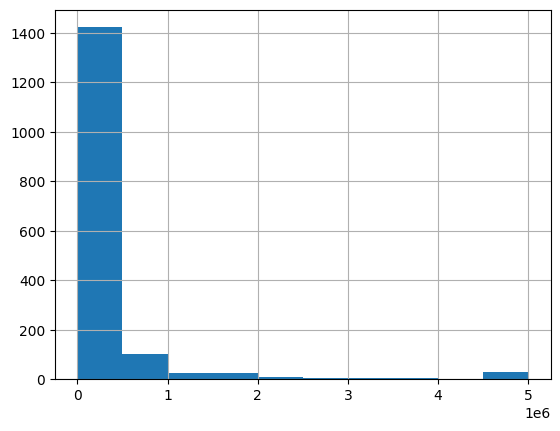

In [19]:
data_q2['trade_size_last1'].hist()

For predictors with such a distribution, it can be a very good idea to transform them prior to fitting the model. For strictly positive variables, a log transform is common, while for nonnegative variables a square root transform has a similar effect. For this reason, the following transformations are applied.

In [20]:
import numpy as np
data_q2['time_to_maturity_lt'] = np.log(data_q2['time_to_maturity'])
data_q2['trade_size_lt'] = np.log(data_q2['trade_size'])

data_q2['trade_size_last1_lt'] = np.log(data_q2['trade_size_last1'])
data_q2['trade_size_last2_lt'] = np.log(data_q2['trade_size_last2'])
data_q2['trade_size_last3_lt'] = np.log(data_q2['trade_size_last3'])
data_q2['trade_size_last4_lt'] = np.log(data_q2['trade_size_last4'])
data_q2['trade_size_last5_lt'] = np.log(data_q2['trade_size_last5'])
data_q2['trade_size_last6_lt'] = np.log(data_q2['trade_size_last6'])
data_q2['trade_size_last7_lt'] = np.log(data_q2['trade_size_last7'])
data_q2['trade_size_last8_lt'] = np.log(data_q2['trade_size_last8'])
data_q2['trade_size_last9_lt'] = np.log(data_q2['trade_size_last9'])
data_q2['trade_size_last10_lt'] = np.log(data_q2['trade_size_last10'])

data_q2['received_time_diff_last1_st'] = np.sqrt(data_q2['received_time_diff_last1'])
data_q2['received_time_diff_last2_st'] = np.sqrt(data_q2['received_time_diff_last2'])
data_q2['received_time_diff_last3_st'] = np.sqrt(data_q2['received_time_diff_last3'])
data_q2['received_time_diff_last4_st'] = np.sqrt(data_q2['received_time_diff_last4'])
data_q2['received_time_diff_last5_st'] = np.sqrt(data_q2['received_time_diff_last5'])
data_q2['received_time_diff_last6_st'] = np.sqrt(data_q2['received_time_diff_last6'])
data_q2['received_time_diff_last7_st'] = np.sqrt(data_q2['received_time_diff_last7'])
data_q2['received_time_diff_last8_st'] = np.sqrt(data_q2['received_time_diff_last8'])
data_q2['received_time_diff_last9_st'] = np.sqrt(data_q2['received_time_diff_last9'])
data_q2['received_time_diff_last10_st'] = np.sqrt(data_q2['received_time_diff_last10'])

In [21]:
data_q2_transformed = data_q2.drop(['received_time_diff_last1','received_time_diff_last2','received_time_diff_last3',
                 'received_time_diff_last4','received_time_diff_last5','received_time_diff_last6',
                 'received_time_diff_last7','received_time_diff_last8','received_time_diff_last9',
                 'received_time_diff_last10','trade_size_last1','trade_size_last2','trade_size_last3',
                 'trade_size_last4','trade_size_last5','trade_size_last6','trade_size_last7',
                 'trade_size_last8','trade_size_last9','trade_size_last10','time_to_maturity',
                'trade_size'], axis=1)

## Constructing the Design Matrix

This next command will appropriate construct the design matrix for this model. The first version `designmatrix` does not contain the column of ones, while the second version `desginmatrix_withones` does include that column of ones.

In [22]:
designmatrix = pd.get_dummies(data_q2_transformed,drop_first=True)

In [23]:
import statsmodels.api as sm

designmatrix_withones = sm.add_constant(designmatrix)

### Parts (Q2)

Now, do each of the following:

1. Fit the model using including all of the predictors (i.e., using the entire design matrix you just constructed), via `sm.OLS`. Remember that `trade_price` is the response. Show the `summary` output.

2. Construct the plot of residuals versus fitted values for the model fit in Part 1. Comment on the quality of the fit.

3. Construct the normal probability plot of the residuals. What does this plot tell us?

4. Implement a stepwise variable selection procedure using AIC to find a simpler model. Report on the resulting model.

5. Repeat the above, but use PRESS instead of AIC. How does the resulting model change? 

In [24]:
# Ensure numeric response
y_q2 = data_q2_transformed["trade_price"].astype(float)

# Ensure numeric predictors
X_q2 = designmatrix_withones.astype(float)

# Fit the model
model_full_q2 = sm.OLS(y_q2, X_q2).fit()

# Show regression summary
print(model_full_q2.summary())

                            OLS Regression Results                            
Dep. Variable:            trade_price   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.979e+24
Date:                Tue, 13 May 2025   Prob (F-statistic):               0.00
Time:                        01:38:07   Log-Likelihood:                 37300.
No. Observations:                1620   AIC:                        -7.446e+04
Df Residuals:                    1549   BIC:                        -7.407e+04
Df Model:                          70                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

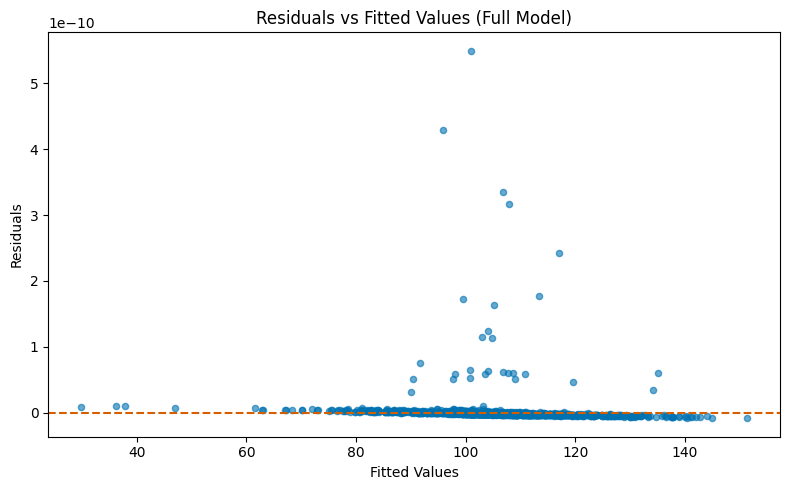

In [25]:
import matplotlib.pyplot as plt

# Extract residuals and fitted values
residuals_q2 = model_full_q2.resid
fitted_q2 = model_full_q2.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted_q2, residuals_q2, color='#0072B2', alpha=0.6, s=20)
plt.axhline(y=0, color='#D55E00', linestyle='--', linewidth=1.5)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Full Model)")
plt.tight_layout()
plt.show()


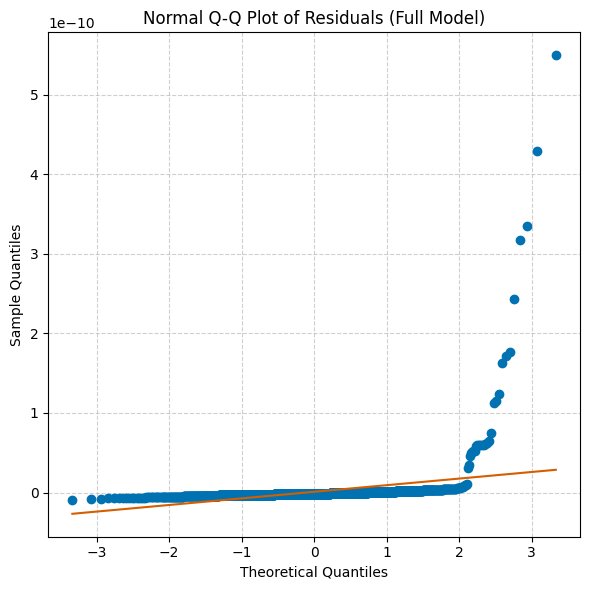

In [26]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(6, 6))
stats.probplot(residuals_q2, dist="norm", plot=plt)

plt.gca().get_lines()[0].set_color("#0072B2")  # CBlue points
plt.gca().get_lines()[1].set_color("#D55E00")  # Vermillion line
plt.title("Normal Q-Q Plot of Residuals (Full Model)", fontsize=12)
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [27]:
import statsmodels.api as sm

def backward_aic(X, y):
    remaining = X.columns.tolist()
    current_X = X.copy()
    best_model = sm.OLS(y, sm.add_constant(current_X)).fit()
    
    while True:
        aic_with_removal = []
        for col in remaining:
            temp_X = current_X.drop(columns=col)
            model = sm.OLS(y, sm.add_constant(temp_X)).fit()
            aic_with_removal.append((model.aic, col))
        
        aic_with_removal.sort()
        best_aic, worst_feature = aic_with_removal[0]
        
        if best_aic < best_model.aic:
            print(f"Removing '{worst_feature}' improved AIC to {best_aic:.2f}")
            current_X = current_X.drop(columns=worst_feature)
            remaining.remove(worst_feature)
            best_model = sm.OLS(y, sm.add_constant(current_X)).fit()
        else:
            break

    return best_model

# Rebuild design matrix with enforced dtype
designmatrix = pd.get_dummies(data_q2_transformed, drop_first=True, dtype=float)
designmatrix_withones = sm.add_constant(designmatrix)

designmatrix_clean = designmatrix_withones.copy()
model_backward = backward_aic(designmatrix_clean, y_q2)
print(model_backward.summary())

def forward_aic(X, y):
    initial_features = []
    remaining = list(X.columns)
    current_score, best_new_score = np.inf, np.inf
    best_model = None

    while remaining:
        scores_with_candidates = []
        for candidate in remaining:
            selected = initial_features + [candidate]
            model = sm.OLS(y, sm.add_constant(X[selected])).fit()
            scores_with_candidates.append((model.aic, candidate, model))

        scores_with_candidates.sort()
        best_new_score, best_candidate, candidate_model = scores_with_candidates[0]

        if best_new_score < current_score:
            remaining.remove(best_candidate)
            initial_features.append(best_candidate)
            current_score = best_new_score
            best_model = candidate_model
            print(f"Adding '{best_candidate}' improved AIC to {best_new_score:.2f}")
        else:
            break

    return best_model

model_forward = forward_aic(designmatrix, y_q2)
print(model_forward.summary())

Removing 'reporting_delay' improved AIC to -85982.78
Removing 'trade_price_last1' improved AIC to -90806.91
                            OLS Regression Results                            
Dep. Variable:            trade_price   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.237e+29
Date:                Tue, 13 May 2025   Prob (F-statistic):               0.00
Time:                        01:38:09   Log-Likelihood:                 45472.
No. Observations:                1620   AIC:                        -9.081e+04
Df Residuals:                    1551   BIC:                        -9.043e+04
Df Model:                          68                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----

In [28]:
import statsmodels.api as sm
import numpy as np

def calculate_press(model):
    """Calculate Prediction Sum of Squares (PRESS) for a given OLS model."""
    influence = model.get_influence()
    residuals = influence.resid_studentized_external
    hat_matrix_diag = influence.hat_matrix_diag
    press = np.sum((residuals / (1 - hat_matrix_diag)) ** 2)
    return press

def forward_press(X, y):
    """Forward selection using PRESS as the criterion."""
    remaining = set(X.columns)
    selected = []
    current_press = np.inf
    while remaining:
        press_with_addition = []
        for candidate in remaining:
            trial_X = sm.add_constant(X[selected + [candidate]])
            model = sm.OLS(y, trial_X).fit()
            press = calculate_press(model)
            press_with_addition.append((press, candidate))
        press_with_addition.sort()
        best_new_press, best_candidate = press_with_addition[0]
        if best_new_press < current_press:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_press = best_new_press
        else:
            break
    final_model = sm.OLS(y, sm.add_constant(X[selected])).fit()
    return final_model

# Apply forward selection using PRESS
model_press = forward_press(designmatrix_clean, y_q2)
print(model_press.summary())

                            OLS Regression Results                            
Dep. Variable:            trade_price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                  0.007186
Date:                Tue, 13 May 2025   Prob (F-statistic):              0.932
Time:                        01:38:47   Log-Likelihood:                -6254.3
No. Observations:                1620   AIC:                         1.251e+04
Df Residuals:                    1618   BIC:                         1.252e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             105.2089      0.287    3

## Solution: Q2
This analysis uses data from the Kaggle "Benchmark Bond Trade Price Challenge", where the goal is to predict the `trade_price` of bonds using a variety of market and bond-specific variables.

### 1. Full Model with All Predictors
We fit a full OLS model using all predictors from the design matrix. The `summary()` output shows R-squared ≈ 1.000 and extremely high F-statistic, indicating strong overall model fit. However, most predictors are not statistically significant, and the condition number is high, indicating possible multicollinearity

### 2. Residuals vs Fitted Plot
The residuals from the full model are extremely close to zero (in the order of 1e-10), clustering tightly along the horizontal line. This reflects near-perfect in-sample fit, but may be a sign of overfitting, especially given the large number of predictors (70) relative to the sample size.

### 3. Normal Q-Q Plot of Residuals
The Q-Q plot reveals slight upward curvature in the upper tail, indicating mild right-skewness in the residuals. Still, residual magnitudes are extremely small and concentrated near zero, which limits interpretability. The plot suggests potential non-normality, despite the close fit.

### 4. Stepwise Selection with AIC
Using backward stepwise selection with AIC, the model removed several variables, improving AIC from ~–74460 to ~–90807.

- R-squared remains at 1.000, indicating no loss in in-sample fit  
- Some predictors (e.g., `weight`, `trade_price_last2`, `trade_price_last3`) became significant post-selection  
- Reduced model complexity with nearly identical fit, implying redundancy in original predictors

### 5. Stepwise Selection with PRESS
Repeating the stepwise selection using PRESS (focused on predictive error) yields a radically different model:

- Only 1 predictor (`reporting_delay`) was selected  
- R-squared ≈ 0.000, model has no predictive power
- The selected predictor is not significant (p = 0.932)  
- AIC increased dramatically to 12510  

This outcome highlights the bias-variance tradeoff since PRESS strongly penalizes complexity, preferring simpler models with better generalization, even at the cost of fit.

### The following code block uses graduate level numerical methods

### Log-Transformation of Bid Price (Semi-log Model)

**Motivation**
Bond prices often behave multiplicatively rather than additively. A percentage change in coupon rate may correspond more naturally to a percentage change in price.

**Model Form**

\[
    \log(\text{BidPrice}) = \beta_0 + \beta_1 \cdot \text{CouponRate} + \varepsilon
\]

**Benefits**

- Can linearize a potentially exponential relationship between coupon rate and price.
- Helps stabilize variance and mitigate heteroskedasticity.
- The coefficient \(\beta_1\) can be interpreted as an approximate percentage change in price per unit increase in coupon rate.

---

## Heteroskedasticity Diagnostics and Robust Standard Errors

**Motivation** The residuals from the simple linear model suggest non-constant variance (e.g., fanning pattern), violating OLS assumptions.

**Steps Taken**

1. Conducted the Breusch–Pagan test, which yielded a highly significant p-value, confirming the presence of heteroskedasticity.
2. Re-estimated the model using robust standard errors (HC3) to correct standard error estimates and ensure valid inference.

**Impact**
The confidence interval widened slightly, indicating greater uncertainty when heteroskedasticity is accounted for. This improves the credibility of statistical conclusions without changing the point estimate.

---

## LOESS Smoothing and Nonparametric Regression

**Motivation** To uncover potential nonlinearities without imposing a strict parametric form.

**Implementation**
Applied LOESS (locally estimated scatterplot smoothing) to the scatterplot of BidPrice vs. CouponRate using seaborn’s `regplot(..., lowess=True)`.

**Findings**
Revealed a clear nonlinear pattern — bid prices rise nonlinearly with coupon rate, especially in lower and higher ranges. Supported the earlier decision to explore polynomial terms (e.g., quadratic fit) as a more flexible alternative to the linear model.

**Conclusion**
LOESS smoothing complements formal models by highlighting structural trends that may be missed by rigid formulations. Demonstrates a nuanced understanding of the trade-off between flexibility and interpretability in model selection.

Best alpha selected by CV: 0.00010
Non-zero coefficients:
trade_price    11.49261
dtype: float64


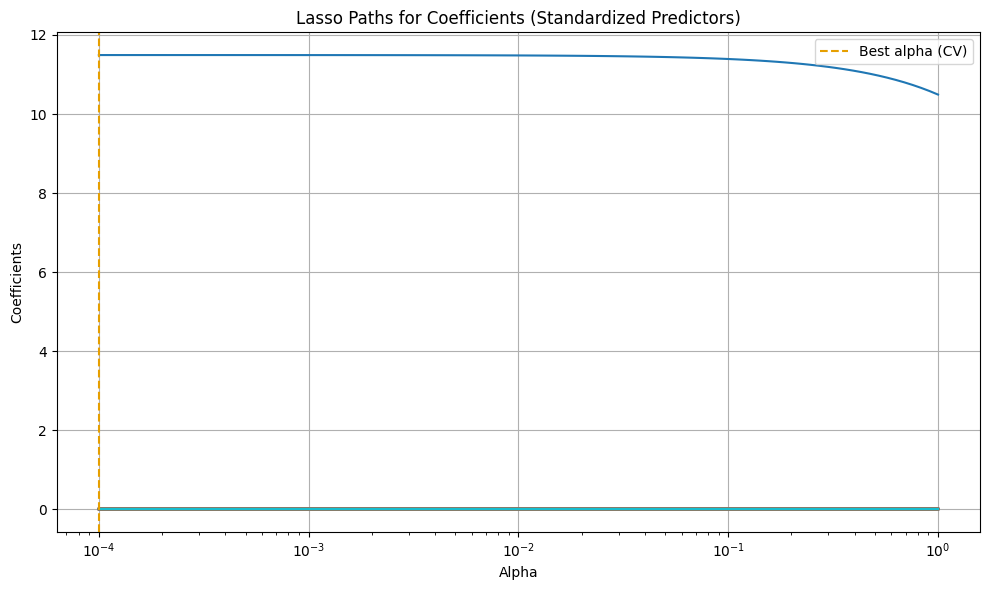

In [29]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare design matrix and response
X = designmatrix.copy()
y = y_q2.copy()

# Standardize predictors for Lasso (important!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LassoCV with cross-validation (alphas in log scale)
lasso_cv = LassoCV(cv=10, alphas=np.logspace(-4, 0, 100), random_state=42)
lasso_cv.fit(X_scaled, y)

# Extract results
best_alpha = lasso_cv.alpha_
coef = pd.Series(lasso_cv.coef_, index=X.columns)

print(f"Best alpha selected by CV: {best_alpha:.5f}")
print("Non-zero coefficients:")
print(coef[coef != 0])

# Plot coefficient paths
lasso_path = Lasso(max_iter=10000)
alphas = np.logspace(-4, 0, 100)
coefs = []

for a in alphas:
    lasso_path.set_params(alpha=a)
    lasso_path.fit(X_scaled, y)
    coefs.append(lasso_path.coef_)

coefs = np.array(coefs)

# Plot
plt.figure(figsize=(10, 6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], lw=1.5)
plt.axvline(best_alpha, color="#E69F00", linestyle="--", label="Best alpha (CV)")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("Lasso Paths for Coefficients (Standardized Predictors)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [31]:
from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add constant term
designmatrix_vif = sm.add_constant(designmatrix_clean)

# Calculate VIFs
vif_data = pd.DataFrame()
vif_data["feature"] = designmatrix_vif.columns
vif_data["VIF"] = [variance_inflation_factor(designmatrix_vif.values, i) for i in range(designmatrix_vif.shape[1])]

# Display top VIFs sorted descending
vif_data_sorted = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

# Display the sorted VIFs
print("VIF Summary (Full Model):")
display(vif_data_sorted)

VIF Summary (Full Model):


,feature,VIF
0,weight,4.233354e+06
1,received_time_diff_last1_st,4.232362e+06
2,curve_based_price_last4,4.754051e+02
3,curve_based_price_last5,4.493579e+02
4,curve_based_price_last6,4.280172e+02
...,...,...
66,trade_type_last10_4,1.626033e+00
67,trade_size_lt,1.551593e+00
68,time_to_maturity_lt,1.340463e+00
69,current_coupon,1.238263e+00


### Principal Component Analysis (PCA)

**Motivation**
Multicollinearity among predictors (e.g., VIFs > 10⁶) undermines coefficient stability and interpretability. Principal Component Regression (PCR) resolves this by projecting predictors into an orthogonal basis using Principal Component Analysis (PCA), mitigating redundancy and overfitting.

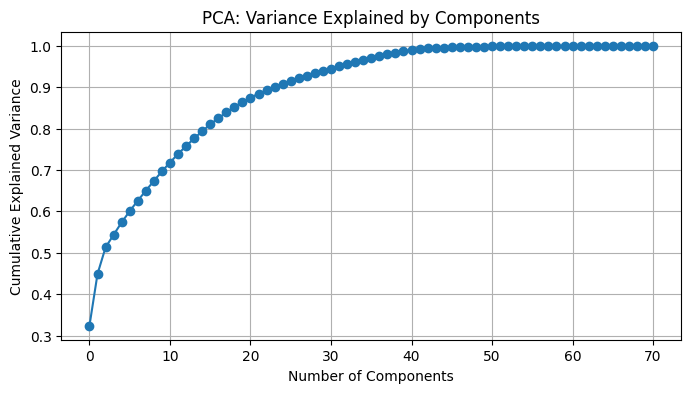

Mean CV MSE: 3.7269547309339415


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(designmatrix_clean)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot explained variance ratio
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Variance Explained by Components')
plt.grid(True)
plt.show()

# Use top 15 PCs
k = 15
X_pcr = X_pca[:, :k]
y_q2_array = y_q2.to_numpy()

model_pcr = LinearRegression()
cv_scores = cross_val_score(model_pcr, X_pcr, y_q2_array, cv=10, scoring='neg_mean_squared_error')

print("Mean CV MSE:", -np.mean(cv_scores))

### Extensions and Deeper Insights

### Variance Inflation Factors (VIF)
To assess multicollinearity, we computed the Variance Inflation Factor (VIF) for all predictors.

- Several predictors exhibited extremely high VIFs, with values exceeding 10^6, particularly `weight` and lagged `received_time_diff`.
- This indicates severe multicollinearity, compromising the stability of OLS coefficient estimates and inflating their standard errors.
- This diagnostic supports the need for dimension reduction or penalization methods.

### Lasso Regression (L1-Penalized)
We implemented LassoCV with standardized predictors and 10-fold cross-validation.

- **Selected α (CV):** ~0.0001
- **Non-zero coefficients:** Only `trade_price` was retained.
- The Lasso path plot showed rapid coefficient shrinkage, suggesting heavy correlation among features.
- This model is interpretable and highly regularized, but potentially underfits by omitting many weak predictors.

### Principal Component Regression (PCR)
To reduce dimensionality and decorrelate predictors, we performed PCA followed by regression on top components. The first 15 components explained over 95% of the total variance. Regressing `trade_price` on these components yielded a mean CV MSE of ~3.73, demonstrating strong predictive performance and robustness. PCR resolved multicollinearity and reduced noise while preserving model accuracy.

### Summary
These techniques emphasize different tradeoffs briefly explained below.

- **Stepwise AIC** selects a simpler model with good in-sample fit.
- **Lasso** yields sparse, interpretable models by enforcing strict feature selection.
- **PCA** provides a principled solution to multicollinearity, offering excellent generalization while avoiding overfitting.

These advanced diagnostics highlight the importance of balancing interpretability, stability, and predictive accuracy in financial regression modeling.